In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

y_train = pd.read_csv('Dataset/y_train_stock_fpt.csv').drop(columns=['Unnamed: 0'])
y_test = pd.read_csv('Dataset/y_test_stock_fpt.csv').drop(columns=['Unnamed: 0'])
y_val = pd.read_csv('Dataset/y_val_stock_fpt.csv').drop(columns=['Unnamed: 0'])

X_train = pd.read_csv('Dataset/x_train_stock_fpt.csv').drop(columns=['Unnamed: 0'])
X_test = pd.read_csv('Dataset/x_test_stock_fpt.csv').drop(columns=['Unnamed: 0'])
X_val = pd.read_csv('Dataset/x_val_stock_fpt.csv').drop(columns=['Unnamed: 0'])

# Create Pytorch Dataset

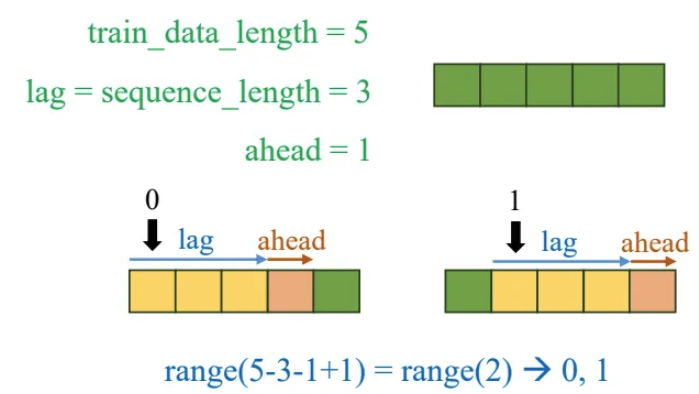

In [3]:
from numpy.lib.stride_tricks import sliding_window_view

# this method is important, it is use to create time-series sequence
def create_sequences(X: pd.DataFrame, 
                     y: pd.DataFrame, 
                     lag: int, 
                     ahead: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Vectorized version to create time series sequences.
    """
    X_values = X.values  # shape: (n_samples, n_features)
    y_values = y.values  # shape: (n_samples, 1)
    
    # Create sliding windows for features (X)
    X_windows = sliding_window_view(X_values, window_shape=lag, axis=0).transpose(0, 2, 1) # (n_sequences, timesteps, n_features)
    
    # Create sliding windows for labels (y)
    y_windows = sliding_window_view(y_values, window_shape=lag + ahead, axis=0).transpose(0, 2, 1) # (n_sequences, timesteps, n_features)
    y_seq = y_windows[:, lag, :].flatten() # take only the 'ahead' part after lag ; shape: (n_sequences, )
    length = len(y_seq)

    X_seq = X_windows[:length]
   
    return X_seq, y_seq

In [4]:
X_train, y_train = create_sequences(X_train, y_train, 30, 1)
X_val, y_val = create_sequences(X_val, y_val, 30, 1)
X_test, y_test = create_sequences(X_test, y_test, 30, 1)

In [30]:
X_test[0]

array([[-0.15254237, -0.58173111, -0.57884236, -0.57875725, -0.57585361],
       [ 0.71186441, -0.58173111, -0.57295106, -0.57875725, -0.57585361],
       [ 0.23163842, -0.57583801, -0.57884236, -0.57875725, -0.57585361],
       [ 0.14124294, -0.58173111, -0.57884236, -0.57875725, -0.58174682],
       [ 0.93785311, -0.58173111, -0.57295106, -0.57875725, -0.57585361],
       [-0.06214689, -0.57583801, -0.57295106, -0.57286288, -0.57585361],
       [-0.04519774, -0.57583801, -0.57295106, -0.57286288, -0.56996041],
       [-0.42372881, -0.57583801, -0.57295106, -0.57286288, -0.57585361],
       [ 0.66101695, -0.57583801, -0.57884236, -0.57286288, -0.57585361],
       [ 3.78531073, -0.57583801, -0.57884236, -0.57875725, -0.57585361],
       [ 0.32768362, -0.57583801, -0.57295106, -0.57286288, -0.57585361],
       [-0.29943503, -0.57583801, -0.57884236, -0.57875725, -0.58174682],
       [ 0.95480226, -0.57583801, -0.57884236, -0.58406219, -0.58174682],
       [-0.14124294, -0.58173111, -0.5

In [31]:
X_test[1]

array([[ 0.71186441, -0.58173111, -0.57295106, -0.57875725, -0.57585361],
       [ 0.23163842, -0.57583801, -0.57884236, -0.57875725, -0.57585361],
       [ 0.14124294, -0.58173111, -0.57884236, -0.57875725, -0.58174682],
       [ 0.93785311, -0.58173111, -0.57295106, -0.57875725, -0.57585361],
       [-0.06214689, -0.57583801, -0.57295106, -0.57286288, -0.57585361],
       [-0.04519774, -0.57583801, -0.57295106, -0.57286288, -0.56996041],
       [-0.42372881, -0.57583801, -0.57295106, -0.57286288, -0.57585361],
       [ 0.66101695, -0.57583801, -0.57884236, -0.57286288, -0.57585361],
       [ 3.78531073, -0.57583801, -0.57884236, -0.57875725, -0.57585361],
       [ 0.32768362, -0.57583801, -0.57295106, -0.57286288, -0.57585361],
       [-0.29943503, -0.57583801, -0.57884236, -0.57875725, -0.58174682],
       [ 0.95480226, -0.57583801, -0.57884236, -0.58406219, -0.58174682],
       [-0.14124294, -0.58173111, -0.58473365, -0.58406219, -0.58705071],
       [ 0.12429379, -0.58173111, -0.5

In [32]:
X_test[2]

array([[ 0.23163842, -0.57583801, -0.57884236, -0.57875725, -0.57585361],
       [ 0.14124294, -0.58173111, -0.57884236, -0.57875725, -0.58174682],
       [ 0.93785311, -0.58173111, -0.57295106, -0.57875725, -0.57585361],
       [-0.06214689, -0.57583801, -0.57295106, -0.57286288, -0.57585361],
       [-0.04519774, -0.57583801, -0.57295106, -0.57286288, -0.56996041],
       [-0.42372881, -0.57583801, -0.57295106, -0.57286288, -0.57585361],
       [ 0.66101695, -0.57583801, -0.57884236, -0.57286288, -0.57585361],
       [ 3.78531073, -0.57583801, -0.57884236, -0.57875725, -0.57585361],
       [ 0.32768362, -0.57583801, -0.57295106, -0.57286288, -0.57585361],
       [-0.29943503, -0.57583801, -0.57884236, -0.57875725, -0.58174682],
       [ 0.95480226, -0.57583801, -0.57884236, -0.58406219, -0.58174682],
       [-0.14124294, -0.58173111, -0.58473365, -0.58406219, -0.58705071],
       [ 0.12429379, -0.58173111, -0.58473365, -0.58406219, -0.58705071],
       [ 0.10734463, -0.58173111, -0.5

In [26]:
y_test

array([-0.558174  , -0.5640672 , -0.5640672 , ..., -1.86116175,
       -1.86116175, -1.86705496])

In [5]:
import torch
from torch.utils.data import Dataset

class StockDataset(Dataset):
    def __init__(self, X:np.ndarray, y:np.ndarray):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        features = self.X[idx]
        targets = self.y[idx]

        return torch.tensor(features, dtype = torch.float32), torch.tensor(targets, dtype = torch.float32)

In [6]:
train_dataset = StockDataset(
    X_train, 
    y_train,
)

val_dataset = StockDataset(
    X_val, 
    y_val,
)

test_dataset = StockDataset(
    X_test, 
    y_test,
)

In [7]:
sample_id = 2

# Check 0-th sample and dataset length
text0, label0 = train_dataset[sample_id]
print(f"Train 0-th sample - text shape: {text0.shape}, label: {label0}")
print(f"Train dataset length: {len(train_dataset)}")

text0_val, label0_val = val_dataset[sample_id]
print(f"Val 0-th sample - text shape: {text0_val.shape}, label: {label0_val}")
print(f"Val dataset length: {len(val_dataset)}")

text0_test, label0_test = test_dataset[sample_id]
print(f"Test 0-th sample - text shape: {text0_test.shape}, label: {label0_test}")
print(f"Test dataset length: {len(test_dataset)}")


Train 0-th sample - text shape: torch.Size([30, 5]), label: -2.001420021057129
Train dataset length: 73894
Val 0-th sample - text shape: torch.Size([30, 5]), label: -0.6719128489494324
Val dataset length: 24612
Test 0-th sample - text shape: torch.Size([30, 5]), label: -0.5640671849250793
Test dataset length: 32826


In [8]:
from torch.utils.data import Dataset, DataLoader

test_batch_size = 512
train_batch_size = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=test_batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False,
)

In [9]:
next(iter(train_loader))[0].shape

torch.Size([1024, 30, 5])

In [10]:
next(iter(train_loader))[1].shape

torch.Size([1024])

# Build Model LSTM

In [11]:
from typing import Literal
import copy
class ModelTraining:
    def __init__(self, model, optimizer, loss_function, device,
                 train_loader, val_loader, test_loader, best_state=None):
        self.model = model
        self.optim = optimizer
        self.loss_fn = loss_function
        self.device = device
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.best_state = best_state

    def calculate_loss_metric_score(self, loader, state: Literal['Train', 'Val', 'Test']):
        """
        Calculate loss and store values used to measure model's performance for each epoch

        Return
            Total loss for each epoch
            Lists of values (for each epoch) used to measure model's performance
        """
        total_loss = 0.0
        total_samples = 0
        y_label_pred = []
        y_label_true = []

        for x, y in loader:
            y = y.to(self.device)
            x = x.to(self.device)

            output = self.model(x) # (B, 1)

            loss = self.loss_fn(output.squeeze(1), y)

            total_loss += loss.item() * len(y)
            total_samples += len(y)

            y_label_true.extend(y.tolist())
            y_label_pred.extend(output.squeeze(1).tolist())

            if state == 'Train':
                # reset gradients to avoid gradient accumulation
                self.optim.zero_grad() 
                
                # calculate gradients
                loss.backward()
                
                # update weights
                self.optim.step()

        total_loss /= total_samples

        return y_label_true, y_label_pred, total_loss
    
    def train_performance(self, metric_fn: callable, kwargs: dict):
        """
        Measure performance of model based on specific metric in training for each epoch
        """
        self.model.train()
        y_label_true, y_label_pred, total_loss = self.calculate_loss_metric_score(self.train_loader, 'Train')
        metric_score = metric_fn(y_label_true, y_label_pred, **kwargs)
        
        return total_loss, metric_score

    def val_performance(self, metric_fn: callable, kwargs: dict):
        self.model.eval()
        with torch.no_grad():
            y_label_true, y_label_pred, total_loss = self.calculate_loss_metric_score(self.val_loader, 'Val')
            metric_score = metric_fn(y_label_true, y_label_pred, **kwargs)

            return total_loss, metric_score

    def training_session(self, epochs: int, metric_fn: callable, kwargs: dict|None = None):
        best_score = float('-inf')
        
        train_loss_collection = []
        val_loss_collection = []
        train_score_collection = []
        val_score_collection = []
        
        if kwargs is None:
            kwargs = {}
            
        for epoch in range(1, epochs + 1):
            train_loss, train_score = self.train_performance(metric_fn, kwargs)
            val_loss, val_score = self.val_performance(metric_fn, kwargs)
            
            train_loss_collection.append(train_loss)
            val_loss_collection.append(val_loss)

            train_score_collection.append(train_score)
            val_score_collection.append(val_score)
            
            if val_score > best_score:
                best_score = val_score
                self.best_state = copy.deepcopy(self.model.state_dict())
                print(f"New best score in epoch {epoch}: {val_score}. Saving model parameters...")

            print("=====================")
            print(f"Epoch {epoch} completed")
            print(f"Train Loss: {train_loss:.4f} ; Score: {train_score}")
            print(f"Val Loss: {val_loss:.4f} ; Score: {val_score}")
            print("=====================")
        
        return train_loss_collection, val_loss_collection, train_score_collection, val_score_collection, self.best_state
    
    def testing(self, metric_fn: callable, kwargs: dict|None=None):
        if kwargs is None:
            kwargs = {}
        
        self.model.load_state_dict(self.best_state)
        
        self.model.eval()
        with torch.no_grad():
            y_label_true, y_label_pred, test_loss = self.calculate_loss_metric_score(self.test_loader, 'Test')
            test_score = metric_fn(y_label_true, y_label_pred, **kwargs)

            print(f"Test Loss: {test_loss} ; Score: {test_score}")

        return {'test_loss': test_loss, 'test_score': test_score, 'y_label_true':y_label_true,
               'y_label_pred': y_label_pred}

In [ ]:
from sklearn.metrics import r2_score
from Model.lstm import LSTMModel
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 40

loss_function = nn.HuberLoss()
metric_fn = r2_score

lstm_params = {
              'emb_dim': X_train.shape[2], 
              'hidden_size': 128,
              'num_layers': 1,
              'bidirectional': False,
              'proj_size': 0,
              'pooling_fn': 'attention'
             }

In [16]:
from collections import OrderedDict

model = LSTMModel(**lstm_params)
model = torch.nn.DataParallel(model)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr= 0.001, weight_decay=1e-3) # weight_decay=1e-3

performance = ModelTraining(model=model, optimizer=optimizer, loss_function=loss_function,
                             device=device, train_loader=train_loader, val_loader=val_loader,
                             test_loader=test_loader, best_state=None)

In [17]:
from torchinfo import summary

dummy_input = torch.rand((4, 50, 5)).to(device)

summary(model, input_data=dummy_input)

Layer (type:depth-idx)                        Output Shape              Param #
DataParallel                                  [4, 1]                    --
├─LSTMModel: 1-1                              [2, 1]                    77,697
├─LSTMModel: 1-4                              --                        (recursive)
│    └─LSTMCell: 2-1                          [2, 128]                  69,248
│    └─LSTMCell: 2-4                          --                        (recursive)
│    │    └─LSTM: 3-1                         [2, 50, 128]              69,120
├─LSTMModel: 1-3                              [2, 1]                    --
├─LSTMModel: 1-4                              --                        (recursive)
│    └─LSTMCell: 2-3                          [2, 128]                  --
│    └─LSTMCell: 2-4                          --                        (recursive)
│    │    └─LSTM: 3-2                         [2, 50, 128]              --
│    │    └─GlobalAttentionPooling: 3-3       [

In [18]:
train_loss_collection, val_loss_collection, train_score_collection, val_score_collection, best_state = \
performance.training_session(epochs=epochs, metric_fn=metric_fn, kwargs={})

New best score in epoch 1: 0.9780621639385185. Saving model parameters...
Epoch 1 completed
Train Loss: 0.0396 ; Score: 0.9179675259548347
Val Loss: 0.0007 ; Score: 0.9780621639385185
New best score in epoch 2: 0.9815292291024814. Saving model parameters...
Epoch 2 completed
Train Loss: 0.0135 ; Score: 0.9728916330835043
Val Loss: 0.0006 ; Score: 0.9815292291024814
Epoch 3 completed
Train Loss: 0.0122 ; Score: 0.9755733790497753
Val Loss: 0.0006 ; Score: 0.9813409098583259
New best score in epoch 4: 0.9896285327405692. Saving model parameters...
Epoch 4 completed
Train Loss: 0.0115 ; Score: 0.9770439622416268
Val Loss: 0.0003 ; Score: 0.9896285327405692
Epoch 5 completed
Train Loss: 0.0113 ; Score: 0.9773522651679025
Val Loss: 0.0004 ; Score: 0.9871812801801234
Epoch 6 completed
Train Loss: 0.0111 ; Score: 0.9778514838793436
Val Loss: 0.0005 ; Score: 0.9848482402774134
Epoch 7 completed
Train Loss: 0.0111 ; Score: 0.9777085742171858
Val Loss: 0.0004 ; Score: 0.9880035678217736
New best

In [19]:
from typing import Literal
import math
import itertools
from matplotlib.axes import Axes
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import seaborn as sns

class LinePlot:
    def __init__(self, df:pd.DataFrame):
        self.df = df

    @staticmethod
    def readable_numbers(x: float) -> str:
        """
        takes a large number and formats it into K,M to make it more readable

        Args
            x: float value to format

        Returns
            str: formatted string
        """
        if x >= 1e6:
            s = '{:1.2f}M'.format(x*1e-6)
        else:
            s = '{:1.2f}K'.format(x*1e-3)
        return s
    
    def set_locator(self, axes: Axes):
        """
        Format x, y ticklabels into more readable form

        Args
            axes: matplotlib axes to format x, y ticklabels
        """
        def is_number(x):
            x = x.replace('−', '-')
            try:
                float(x)
                return True
            except ValueError:
                return False
    
        x_ticklabels = [tick.get_text() for tick in axes.get_xticklabels()]
        y_ticklabels = [tick.get_text() for tick in axes.get_yticklabels()]
    
        formatter = FuncFormatter(lambda val, pos: self.readable_numbers(val))

        if is_number(x_ticklabels[0]) == True:
            axes.xaxis.set_major_formatter(formatter)
        if is_number(y_ticklabels[0]) == True:
            axes.yaxis.set_major_formatter(formatter)
    
    def single_plot(
        self,
        x_axis: str,
        y_axis: str,
        hue: str | None = None,
        style: str | None = None,
        size: str | None = None,
        kwarg: dict | None = None,
        readable_label: bool = False,
        ax: Axes = None
    ) -> Axes:
        """
        Draw a visually stunning and readable line plot.
    
        Args:
            x_axis: categorical or numeric column for X-axis
            y_axis: numeric column for Y-axis
            hue: column for line colors (group)
            style: column for line styles (e.g., dashed, dotted)
            size: column for line thickness variation
            kwarg: additional seaborn.lineplot arguments
            readable_label: whether to format axes tick labels into readable form
            ax: matplotlib Axes to draw plot on
        """
    
        if ax is None:
            ax = plt.gca()
            fig = ax.get_figure()
            fig.set_size_inches(10, 6)
        if kwarg is None:
            kwarg = {}

        if hue is not None:
            palette='viridis'
        else:
            palette=None
        # --- 🎨 Line Plot ---
        line = sns.lineplot(
            data=self.df,
            x=x_axis,
            y=y_axis,
            hue=hue,
            style=style,
            size=size,
            ax=ax,
            # marker="o",             # ✅ Add circle markers to each data point
            linewidth=2.2,          # ✅ Slightly thicker lines
            # markersize=4,           # ✅ Larger markers for visibility
            alpha=0.9,              # ✅ Soft transparency for overlapping lines
            palette=palette,      # ✅ Modern, readable color palette
            **kwarg
        )
    
        # --- 🎭 Title & Axis Labels ---
        ax.set_title(
            f"{y_axis} vs {x_axis}",
            fontsize=12,
            fontweight="regular",
            # fontname="Times New Roman",
            # pad=15
        )
        ax.set_xlabel(x_axis, fontsize=12, labelpad=5) # fontname="Times New Roman"
        ax.set_ylabel(y_axis, fontsize=12, labelpad=10) # fontname="Times New Roman"
    
        # --- 📏 Tick Formatting ---
        ax.tick_params(axis="x", rotation=0, labelsize=11)
        ax.tick_params(axis="y", rotation=0, labelsize=11)
        ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
    
        # --- 🎨 Legend ---
        if hue or style or size:
            leg = ax.legend(
                title="Legend",
                title_fontsize=11,
                fontsize=10,
                loc="best",
                frameon=False,
                fancybox=True,
                framealpha=0.9,
            )
            leg.get_frame().set_linewidth(0.7)
            leg.get_frame().set_edgecolor("gray")
    
        # --- 📊 Optional: Format Large Axis Labels ---
        if readable_label:
            self.set_locator(ax)
    
        # --- 💅 Aesthetic Cleanup ---
        sns.despine(ax=ax, top=True, right=True)
    
        return line

    def multiple_plots(self, x_axis_list: list[str], y_axis_list: list[str], hue_list: list[str|None], 
                       kwarg: dict, plots_each_row: int, size_list: list[str|None], style_list: list[str|None],
                       readable_label: bool = False) -> (Figure, np.array([Axes])):
        """
        Draw multiple plots

        Args
            Same as single_plot
            y_axis_list: list of columns for y axis
            x_axis_list: list of columns for x axis
            hue_list
            size_list
            style_list
            plots_each_row: number of plots for each row in matplotlib figure
            kwarg: additional seaborn.lineplot arguments
        """
        
        combination = list(zip(x_axis_list, y_axis_list, hue_list, size_list, style_list))
        
        length = len(combination)
        number_rows = math.ceil(length / plots_each_row)
    
        fig, axes = plt.subplots(nrows=number_rows, ncols=plots_each_row, figsize=(16, 12),
                                sharey=True) # same y_axis scale
        axes = np.array(axes).reshape(number_rows, plots_each_row)
    
        coordinates = list(itertools.product(range(number_rows), range(plots_each_row)))
    
        for coor, com in zip(coordinates, combination):
            x, y, hue, size, style = com
            ax = axes[coor]
            self.single_plot(
                x_axis=x,
                y_axis=y,
                hue=hue,
                size=size,
                style=style,
                readable_label=readable_label,
                kwarg=kwarg,
                ax=ax
            )
    
        # hide any unused axes
        for coor in coordinates[length:]:
            fig.delaxes(axes[coor])

        return fig, axes

In [20]:
df_train = pd.DataFrame({'loss': train_loss_collection,
                        'score': train_score_collection,
                        'type': "train"})

df_val = pd.DataFrame({'loss': val_loss_collection,
                        'score': val_score_collection,
                        'type': "val"})
df = pd.concat((df_train, df_val), axis=0).reset_index()
df['index'] = df['index'] + 1

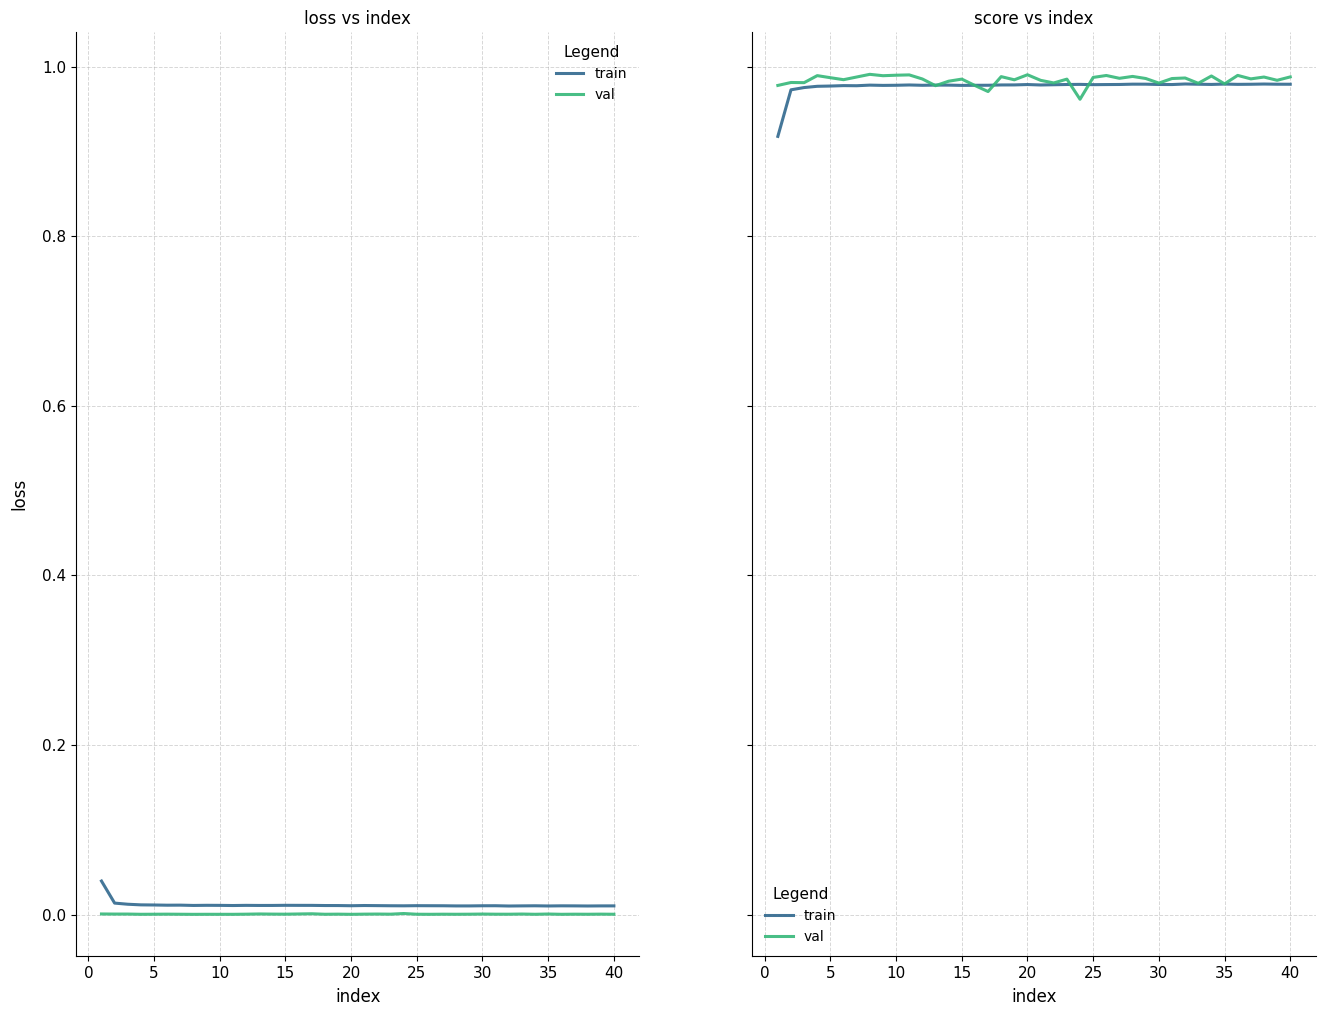

In [21]:
X = ['index', 'index']
y = ['loss', 'score']
hue = ['type', 'type']
style_list = [None for _ in range(2)]
size_list = [None for _ in range(2)]

plotter = LinePlot(df)
fig, axes = plotter.multiple_plots(x_axis_list=X, y_axis_list=y, hue_list=hue,
                                      style_list=style_list, size_list=size_list, plots_each_row=2,
                                      kwarg={}, readable_label=False)

In [22]:
dict_ = performance.testing(metric_fn=metric_fn, kwargs={})

Test Loss: 0.0004987365548124078 ; Score: 0.9975841266425843


In [23]:
dict_['y_label_true'][:20]

[-0.5581740140914917,
 -0.5640671849250793,
 -0.5640671849250793,
 -0.5463876128196716,
 -0.5522807836532593,
 -0.5463876128196716,
 -0.5522807836532593,
 -0.5522807836532593,
 -0.5581740140914917,
 -0.5581740140914917,
 -0.5522807836532593,
 -0.5522807836532593,
 -0.5522807836532593,
 -0.5522807836532593,
 -0.5522807836532593,
 -0.5522807836532593,
 -0.5522807836532593,
 -0.5522807836532593,
 -0.5463876128196716,
 -0.5463876128196716]

In [24]:
dict_['y_label_pred'][:20]

[-0.5626378059387207,
 -0.5620162487030029,
 -0.5615600943565369,
 -0.5606464743614197,
 -0.5590824484825134,
 -0.5581133961677551,
 -0.5573090314865112,
 -0.5566467046737671,
 -0.5559402704238892,
 -0.5554287433624268,
 -0.5553869009017944,
 -0.5546368956565857,
 -0.5537354350090027,
 -0.5530316829681396,
 -0.5518239736557007,
 -0.550625205039978,
 -0.5491353273391724,
 -0.54744553565979,
 -0.5459619164466858,
 -0.5443551540374756]

In [25]:
r2_score(dict_['y_label_true'], dict_['y_label_pred'])

0.9975841266425843

In [ ]:
import os
best_path = os.path.join('/Model', "best_lstm_model.pth") 

torch.save({
    "model_state": best_state,
    "model_class": model.__class__.__name__,
    "model_args": lstm_params,
    "optimizer_state": optimizer.state_dict(),
    "epochs": epochs
}, best_path)